# Example 1 — Neutrino trident events with `neptune`

`neptune` is the sibling package to [DarkNews](https://github.com/mhostert/DarkNews-generator) for the neutrino-trident process
$$
    \nu_\alpha + N \to \nu_\alpha + \ell_1^- + \ell_2^+ + N\,,
$$
computed in both the **coherent nuclear** regime (Woods-Saxon form factor, $\propto Z^2$) and the **diffractive nucleon** regime (proton/neutron dipole form factor, $\propto A$, with Pauli blocking).

This notebook walks through:

1. Building Standard Model and BSM ($Z'$) trident models.
2. Computing total cross sections at a fixed neutrino energy, including a 1D energy scan.
3. Comparing different lepton-flavor channels.
4. Scanning over $(M_{Z'},\,g')$ parameter space.
5. Generating weighted Monte Carlo events with the `TridentGenerator`.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import neptune as nep
print('neptune', nep.__version__)

neptune 0.1.0


## 1) A first cross-section calculation

We start with the dimuon trident channel $\nu_\mu + \mathrm{Ar} \to \nu_\mu \mu^+ \mu^- \mathrm{Ar}$ at $E_\nu = 10\,\mathrm{GeV}$.

The model encapsulates the SM $W+Z$ structure. The process object glues the model to a target nucleus and runs `vegas` to integrate the 6-dim equivalent-photon-approximation phase space.

In [2]:
model = nep.TridentSMModel(nu_flavor='mu', l1_flavor='mu', l2_flavor='mu')
print(model)

# Argon-40
proc = nep.TridentProcess(model, Z=18, A=40, Enu=10.0, nitn=8, neval=20_000)
result = proc.sigma_total()
for k, (mean, sd) in result.items():
    print(f'{k:>22s}: {mean:.3e}  +/-  {sd:.2e}  cm^2')

TridentSMModel(nu=mu, l1=mu, l2=mu, nubar=False)
           diffractive: 4.361e-43  +/-  4.34e-46  cm^2
              coherent: 1.088e-42  +/-  8.07e-46  cm^2
     total_per_nucleus: 1.853e-41  +/-  1.74e-44  cm^2


## 2) Energy scan: $\sigma(E_\nu)$

We sweep $E_\nu$ from a few GeV (above threshold) to ~100 GeV and overlay the coherent and diffractive components. The coherent piece dominates for moderate-mass targets thanks to its $Z^2$ enhancement, but diffractive scattering takes over at the highest energies for heavy targets.

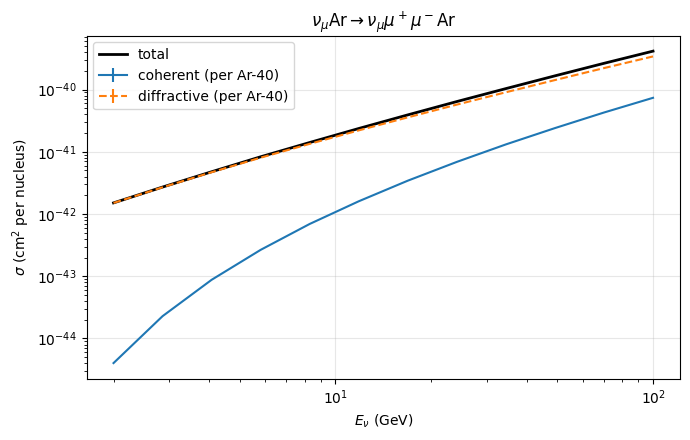

In [3]:
Enu_arr = np.geomspace(2.0, 100.0, 12)
scan = proc.sigma_scan(Enu_arr, nitn=6, neval=10_000)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(Enu_arr, scan['coherent'], yerr=scan['coherent_err'], label='coherent (per Ar-40)')
ax.errorbar(Enu_arr, scan['diffractive'] * proc.A, yerr=scan['diffractive_err'] * proc.A,
             label='diffractive (per Ar-40)', ls='--')
total = scan['coherent'] + scan['diffractive'] * proc.A
ax.plot(Enu_arr, total, 'k-', label='total', lw=2)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$E_\nu$ (GeV)'); ax.set_ylabel(r'$\sigma$ (cm$^2$ per nucleus)')
ax.set_title(r'$\nu_\mu \mathrm{Ar} \to \nu_\mu \mu^+ \mu^- \mathrm{Ar}$')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()

## 3) Channel comparison

Different lepton-flavor combinations have very different SM coupling structures (through $V_{ijk}$ and $A_{ijk}$). We compare three benchmark channels at a fixed energy.

In [4]:
channels = [
    ('mu', 'mu', 'mu'),   # NC-only,  same flavor
    ('e',  'e',  'e'),    # NC + CC interference
    ('mu', 'mu', 'e'),    # mixed (no CC at all)
    ('e',  'e',  'mu'),   # CC dominant
]
rows = []
for nu, l1, l2 in channels:
    m = nep.TridentSMModel(nu_flavor=nu, l1_flavor=l1, l2_flavor=l2)
    p = nep.TridentProcess(m, Z=18, A=40, Enu=20.0, nitn=6, neval=10_000)
    coh, coh_e = p.sigma_coherent()
    dif, dif_e = p.sigma_diffractive()
    rows.append(dict(channel=f'nu_{nu} -> {l1}-{l2}+',
                     sigma_coh=coh, sigma_diff_per_nucleon=dif))
df_ch = pd.DataFrame(rows)
df_ch

,channel,sigma_coh,sigma_diff_per_nucleon
0,nu_mu -> mu-mu+,4.787817e-42,1.116187e-42
1,nu_e -> e-e+,9.281411e-41,4.991913e-42
2,nu_mu -> mu-e+,9.050176e-41,6.892171e-42
3,nu_e -> e-mu+,3.985809e-41,3.683924e-42


## 4) BSM $Z'$ scan

The `TridentBSMModel` adds a vector $Z'$ that couples to charged leptons (and, in our example here, to the nucleus through the $\mathrm{CHARGE}=Z$ assignment in coherent scattering). We hold $g' = 10^{-3}$ and scan in $M_{Z'}$ to see the propagator-driven enhancement at low mass.

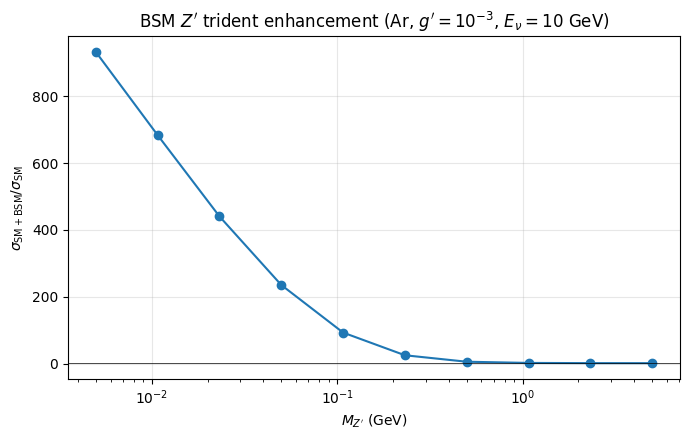

In [5]:
mzprime_arr = np.geomspace(0.005, 5.0, 10)
gprime = 1e-3
Z, A = 18, 40

sm_model = nep.TridentSMModel(nu_flavor='mu', l1_flavor='mu', l2_flavor='mu')
sm_proc = nep.TridentProcess(sm_model, Z=Z, A=A, Enu=10.0, nitn=6, neval=10_000)
sm_coh, _ = sm_proc.sigma_coherent()

ratios = []
for mz in mzprime_arr:
    bsm = nep.TridentBSMModel(
        nu_flavor='mu', l1_flavor='mu', l2_flavor='mu',
        mzprime=mz, gV_prime=gprime, gA_prime=0.0, CHARGE=Z,
    )
    p = nep.TridentProcess(bsm, Z=Z, A=A, Enu=10.0, nitn=6, neval=10_000)
    coh, _ = p.sigma_coherent()
    ratios.append(coh / sm_coh)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(mzprime_arr, ratios, 'o-')
ax.axhline(1.0, color='k', lw=0.5)
ax.set_xscale('log')
ax.set_xlabel(r"$M_{Z'}$ (GeV)"); ax.set_ylabel(r'$\sigma_\mathrm{SM+BSM} / \sigma_\mathrm{SM}$')
ax.set_title(r"BSM $Z'$ trident enhancement (Ar, $g'=10^{-3}$, $E_\nu=10$ GeV)")
ax.grid(alpha=0.3)
plt.tight_layout()

## 5) Generate weighted MC events

The `TridentGenerator` trains a `vegas` importance-sampling map and samples weighted events for both the diffractive and coherent regimes. The output dict gives the kinematic invariants on the unit phase-space hypercube together with `weight` (proportional to $d\sigma$) and `mode` (`'diffractive'` or `'coherent'`).

Here we wrap the dict in a DarkNews-style `pandas.DataFrame` so it can be analysed and merged easily with DarkNews outputs.

In [6]:
model = nep.TridentSMModel(nu_flavor='mu', l1_flavor='mu', l2_flavor='mu')
gen = nep.TridentGenerator(
    model, Z=18, A=40, Enu=10.0,
    n_events=5_000, nitn=6, neval=20_000, seed=0,
)
events = gen.generate(verbose=False)

df = pd.DataFrame({
    ('s',     ''): events['s'],
    ('t',     ''): events['t'],
    ('l',     ''): events['l'],
    ('q',     ''): events['q'],
    ('phi',   ''): events['phi'],
    ('theta', ''): events['theta'],
    ('Enu',   ''): events['Enu'],
    ('w_event_rate', ''): events['weight'],
    ('scattering_regime', ''): events['mode'],
})
df.attrs['model'] = repr(model)
df.attrs['target_pdgid'] = 1000180400  # Ar-40
print(f'Total events: {len(df)},  weight sum (cm^2 per Ar-40): {df[("w_event_rate","")].sum():.3e}')
df.head()

Total events: 36906,  weight sum (cm^2 per Ar-40): 1.520e-42


,s,t,l,q,phi,theta,Enu,w_event_rate,scattering_regime
,,,,,,,,,
0,0.615529,0.180624,-0.125392,0.091251,0.504763,0.413665,10.0,1.745921e-47,diffractive
1,0.358657,0.123784,-0.071148,0.050008,0.910479,0.120859,10.0,3.381852e-48,diffractive
2,1.386841,0.339216,-0.247801,0.238288,0.806317,0.725695,10.0,5.707025e-47,diffractive
3,0.775489,0.062125,-0.012899,0.288833,0.808882,0.190586,10.0,1.860013e-48,diffractive
4,1.282789,0.345421,-0.247166,0.201528,0.970417,0.575174,10.0,4.817698e-47,diffractive


### Kinematic distributions

We can plot the dilepton invariant mass $\sqrt{s}$ and the photon $|q|$ scale of the exchange, for both regimes.

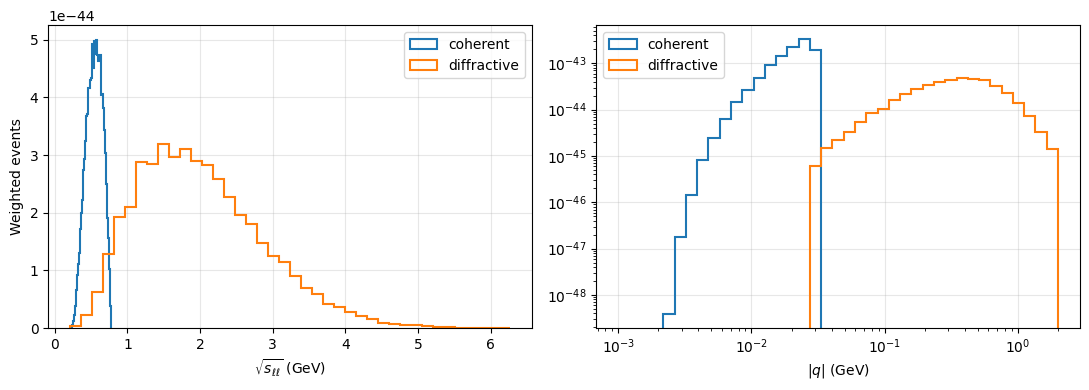

In [7]:
regimes = ['coherent', 'diffractive']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for r in regimes:
    sel = df[('scattering_regime', '')] == r
    sqs = np.sqrt(np.maximum(df[('s', '')][sel], 0.0))
    w   = df[('w_event_rate', '')][sel]
    axes[0].hist(sqs, bins=40, weights=w, histtype='step', label=r, lw=1.5)
    axes[1].hist(df[('q', '')][sel], bins=np.geomspace(1e-3, 2.0, 40),
                  weights=w, histtype='step', label=r, lw=1.5)

axes[0].set_xlabel(r'$\sqrt{s_{\ell\ell}}$ (GeV)')
axes[0].set_ylabel('Weighted events')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel(r'$|q|$ (GeV)')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()

## 6) EPA vs. full coherent integration

By default `TridentProcess` and `TridentGenerator` use the **equivalent-photon approximation** for the coherent regime — a fast 6-D Vegas integration that factorises the nuclear photon flux from the lepton-pair amplitude. Pass `use_epa=False` to switch to the full 8-D coherent matrix element:

```python
proc_full = nep.TridentProcess(model, Z=18, A=40, Enu=10.0, use_epa=False)
```

> **Note.** The full path is currently *experimental*: the polynomial matrix element is auto-translated from the upstream C++ code, but its overall normalisation is still being validated. For production results, prefer the EPA path.

## 7) Where to go next

* Pass a `flux=callable(E_nu)` plus `Emin`/`Emax` to `TridentProcess` or `TridentGenerator` to flux-average and fold in a beam spectrum.
* Switch nuclei via `Z`, `A` (e.g. C-12, $\mathrm{H_2O}$ via two `TridentProcess` instances summed).
* Use the `bsm_mode` attribute of `TridentBSMModel` to isolate SM-only, interference, or BSM-only contributions.
* Couple this to a DarkNews `df.attrs['experiment']` workflow by pulling a `NuclearTarget` via `nep.get_nuclear_target('Ar40')` and reading `Z`, `A` from it.